In [ ]:
from ecg_monitor.pipeline import (
    build_df_all, get_train_test_split,
    bandpass_filter, pan_tompkins_detect, extract_beat_features,
    DATA_DIR, BEAT_SYMBOLS, PACED_RECORDS, LABEL_MAP,
    DS1_RECORDS, DS2_RECORDS, FEATURE_COLS,
)
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.signal import butter, filtfilt, find_peaks
from scipy.stats import kurtosis, skew

In [2]:
  # Read a record's signal
  record = wfdb.rdrecord(f'{DATA_DIR}/207')
  print(record.sig_name)   # ['MLII', 'V5']
  print(record.fs)          # 360 (Hz)
  print(record.p_signal.shape)  # (650000, 2)

['MLII', 'V1']
360
(650000, 2)


In [3]:
  # Read annotations (beat labels)
  ann = wfdb.rdann(f'{DATA_DIR}/207', 'atr')
  print(ann.symbol[:10])   # beat type symbols like 'N', 'V', 'A', etc.
  print(ann.sample[:10])   # sample indices where beats occur


['+', 'R', 'V', 'R', 'V', 'R', 'V', 'R', 'V', 'R']
[   9   50  312  835 1078 1588 1821 2342 2593 3111]


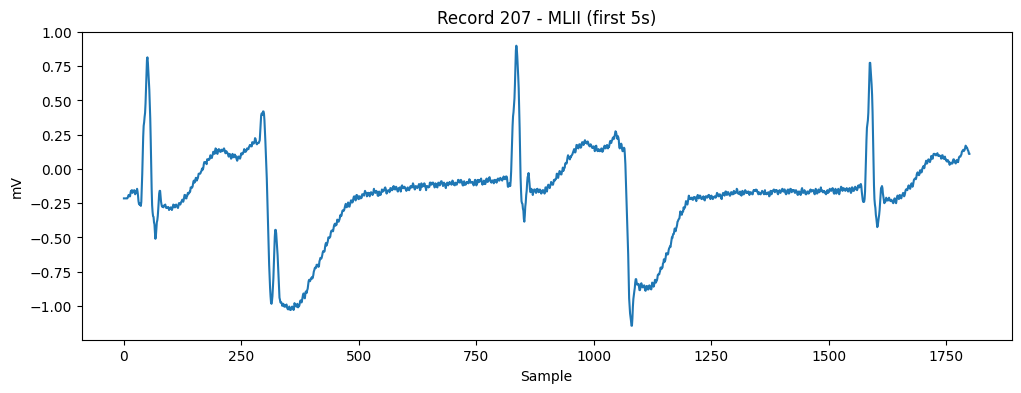

In [4]:
  # Plot first 5 seconds of MLII lead
  samples = 5 * record.fs  # 1800 samples
  plt.figure(figsize=(12, 4))
  plt.plot(record.p_signal[:samples, 0])
  plt.title('Record 207 - MLII (first 5s)')
  plt.xlabel('Sample')
  plt.ylabel('mV')
  plt.show()

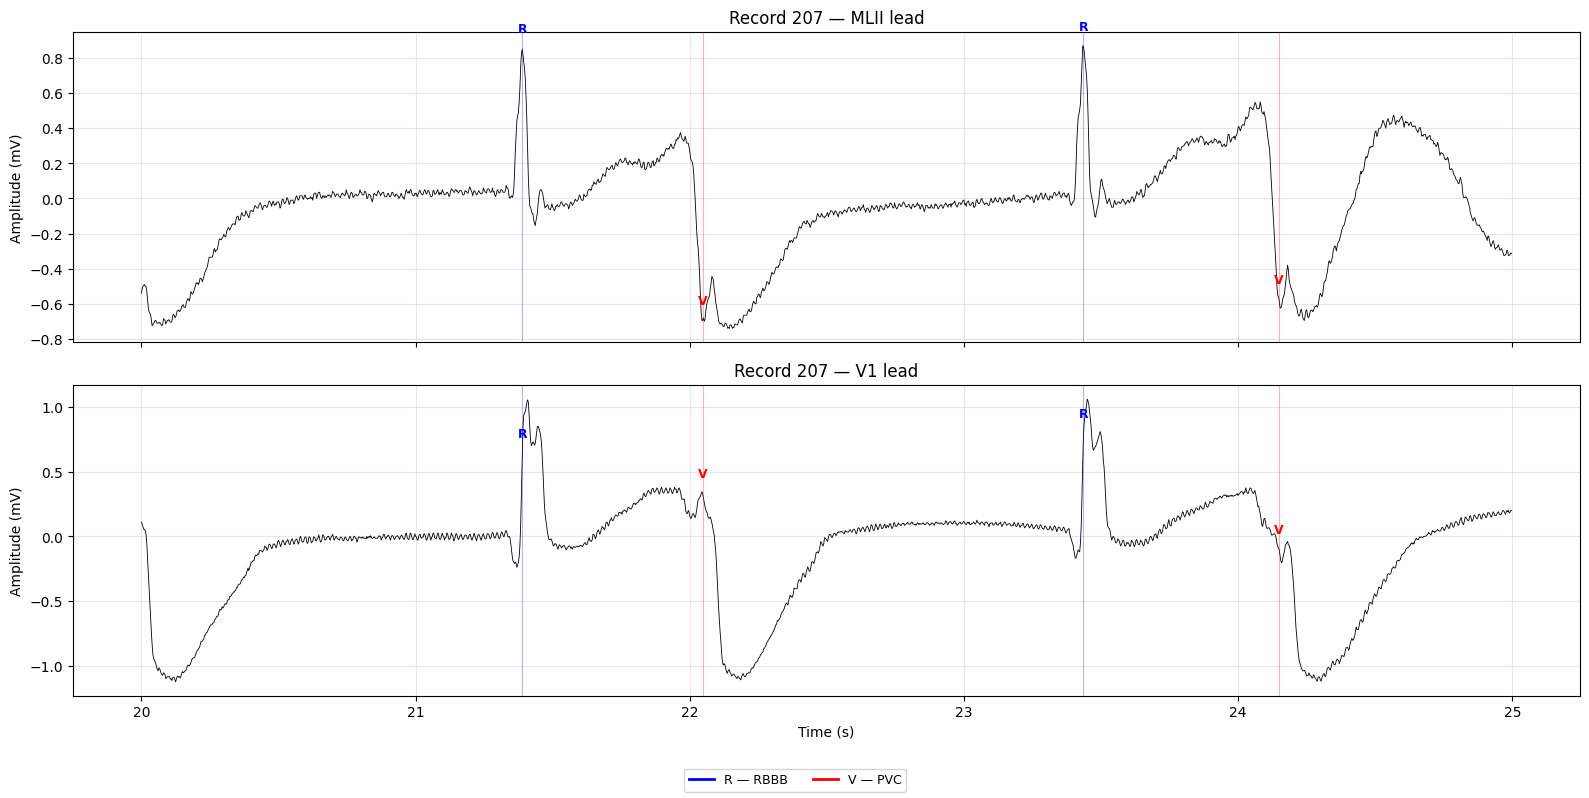

In [5]:
# --- Annotated ECG visualization for Record 207 ---

record = wfdb.rdrecord(f'{DATA_DIR}/207')
ann = wfdb.rdann(f'{DATA_DIR}/207', 'atr')

start_sec, end_sec = 20, 25
start_sample = int(start_sec * record.fs)
end_sample = int(end_sec * record.fs)

time = np.arange(start_sample, end_sample) / record.fs

mask = (ann.sample >= start_sample) & (ann.sample < end_sample)
ann_samples = ann.sample[mask]
ann_symbols = np.array(ann.symbol)[mask]

colors = {'N': 'green', 'A': 'orange', 'V': 'red', 'L': 'purple',
          'R': 'blue', '/': 'cyan', '+': 'gray'}

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, (ch_idx, ch_name) in zip(axes, enumerate(record.sig_name)):
    sig = record.p_signal[start_sample:end_sample, ch_idx]
    ax.plot(time, sig, color='black', linewidth=0.6, label=ch_name)
    for s, sym in zip(ann_samples, ann_symbols):
        t = s / record.fs
        color = colors.get(sym, 'magenta')
        ax.axvline(t, color=color, alpha=0.3, linewidth=0.8)
        ax.annotate(sym, xy=(t, sig[s - start_sample]),
                    xytext=(0, 12), textcoords='offset points',
                    fontsize=9, fontweight='bold', color=color, ha='center')
    ax.set_ylabel('Amplitude (mV)')
    ax.set_title(f'Record 207 — {ch_name} lead')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')

legend_labels = {'N': 'Normal', 'A': 'Atrial premature', 'V': 'PVC',
                 'L': 'LBBB', 'R': 'RBBB', '/': 'Paced', '+': 'Rhythm change'}
present = set(ann_symbols)
handles = [Line2D([0], [0], color=colors.get(s, 'magenta'), linewidth=2,
           label=f'{s} — {legend_labels.get(s, s)}')
           for s in sorted(present) if s in colors]
fig.legend(handles=handles, loc='lower center', ncol=len(handles), fontsize=9)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [ ]:
# --- Pan-Tompkins test on record 100 (functions imported from ecg_pipeline) ---
record = wfdb.rdrecord(f'{DATA_DIR}/100')
detected, filtered = pan_tompkins_detect(record.p_signal[:, 0], record.fs)
print(f"Record 100: {len(detected)} beats detected")

=== Pan-Tompkins Beat Detection (with searchback) — All 48 Records ===

Overall sensitivity: 98.1% (107316/109388)
Overall PPV:         97.5% (107316/110070)
Total FP: 2754   Total FN: 2072

Worst 10 records by sensitivity:
record  true_beats  detected   TP   FP   FN  sensitivity  PPV
   107        2137      2130  966 1164 1171         45.2 45.4
   104        2229      2319 1977  342  252         88.7 85.3
   228        2053      2015 1941   74  112         94.5 96.3
   114        1879      1807 1800    7   79         95.8 99.6
   108        1763      1957 1714  243   49         97.2 87.6
   201        1963      1912 1909    3   54         97.2 99.8
   105        2572      2617 2523   94   49         98.1 96.4
   203        2980      3022 2936   86   44         98.5 97.2
   109        2532      2502 2500    2   32         98.7 99.9
   217        2208      2203 2182   21   26         98.8 99.0


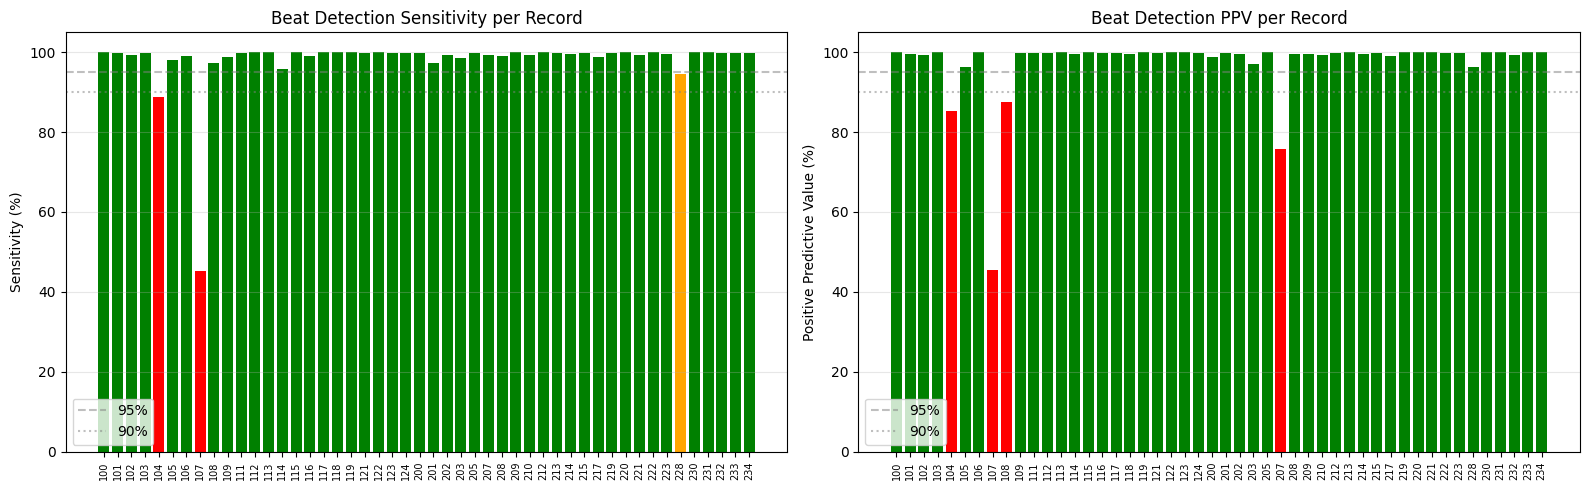

In [7]:
# --- Beat detection evaluation across all 48 records ---

all_records = open(f'{DATA_DIR}/RECORDS').read().strip().split('\n')

results = []
for rec_id in all_records:
    record = wfdb.rdrecord(f'{DATA_DIR}/{rec_id}')
    ann = wfdb.rdann(f'{DATA_DIR}/{rec_id}', 'atr')
    detected, _ = pan_tompkins_detect(record.p_signal[:, 0], record.fs)
    
    beat_mask = np.array([s in BEAT_SYMBOLS for s in ann.symbol])
    true_peaks = ann.sample[beat_mask]
    
    tolerance = int(0.075 * record.fs)
    
    tp = sum(1 for t in true_peaks if np.any(np.abs(detected - t) <= tolerance))
    fn = len(true_peaks) - tp
    fp = sum(1 for d in detected if not np.any(np.abs(true_peaks - d) <= tolerance))
    
    sensitivity = tp / len(true_peaks) * 100 if len(true_peaks) > 0 else 0
    ppv = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    
    results.append({
        'record': rec_id, 'true_beats': len(true_peaks), 'detected': len(detected),
        'TP': tp, 'FP': fp, 'FN': fn, 'sensitivity': sensitivity, 'PPV': ppv,
    })

df_det = pd.DataFrame(results)

# --- Summary ---
total_tp = df_det['TP'].sum()
total_fp = df_det['FP'].sum()
total_fn = df_det['FN'].sum()
total_true = df_det['true_beats'].sum()

print("=== Pan-Tompkins Beat Detection (with searchback) — All 48 Records ===\n")
print(f"Overall sensitivity: {total_tp/total_true*100:.1f}% ({total_tp}/{total_true})")
print(f"Overall PPV:         {total_tp/(total_tp+total_fp)*100:.1f}% ({total_tp}/{total_tp+total_fp})")
print(f"Total FP: {total_fp}   Total FN: {total_fn}\n")

print("Worst 10 records by sensitivity:")
worst = df_det.nsmallest(10, 'sensitivity')
print(worst[['record', 'true_beats', 'detected', 'TP', 'FP', 'FN', 'sensitivity', 'PPV']].round(1).to_string(index=False))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
colors_s = ['red' if s < 90 else 'orange' if s < 95 else 'green' for s in df_det['sensitivity']]
ax.bar(range(len(df_det)), df_det['sensitivity'], color=colors_s)
ax.set_xticks(range(len(df_det)))
ax.set_xticklabels(df_det['record'], rotation=90, fontsize=7)
ax.set_ylabel('Sensitivity (%)')
ax.set_title('Beat Detection Sensitivity per Record')
ax.axhline(95, color='gray', linestyle='--', alpha=0.5, label='95%')
ax.axhline(90, color='gray', linestyle=':', alpha=0.5, label='90%')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
colors_p = ['red' if p < 90 else 'orange' if p < 95 else 'green' for p in df_det['PPV']]
ax.bar(range(len(df_det)), df_det['PPV'], color=colors_p)
ax.set_xticks(range(len(df_det)))
ax.set_xticklabels(df_det['record'], rotation=90, fontsize=7)
ax.set_ylabel('Positive Predictive Value (%)')
ax.set_title('Beat Detection PPV per Record')
ax.axhline(95, color='gray', linestyle='--', alpha=0.5, label='95%')
ax.axhline(90, color='gray', linestyle=':', alpha=0.5, label='90%')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# --- Feature extraction demo on record 100 (function imported from ecg_pipeline) ---
record = wfdb.rdrecord(f'{DATA_DIR}/100')
ann = wfdb.rdann(f'{DATA_DIR}/100', 'atr')
_, filtered = pan_tompkins_detect(record.p_signal[:, 0], record.fs)

df = extract_beat_features(filtered, record.fs, ann.sample, ann.symbol)
print(f"Record 100: {len(df)} beats extracted")
print(f"Beat waveform length: {len(df['beat_waveform'].iloc[0])} samples")
print(f"\nLabel distribution:")
print(df['label'].value_counts().to_string())

In [ ]:
# --- Build full dataset (imported pipeline handles all processing) ---
df_all, pca = build_df_all()

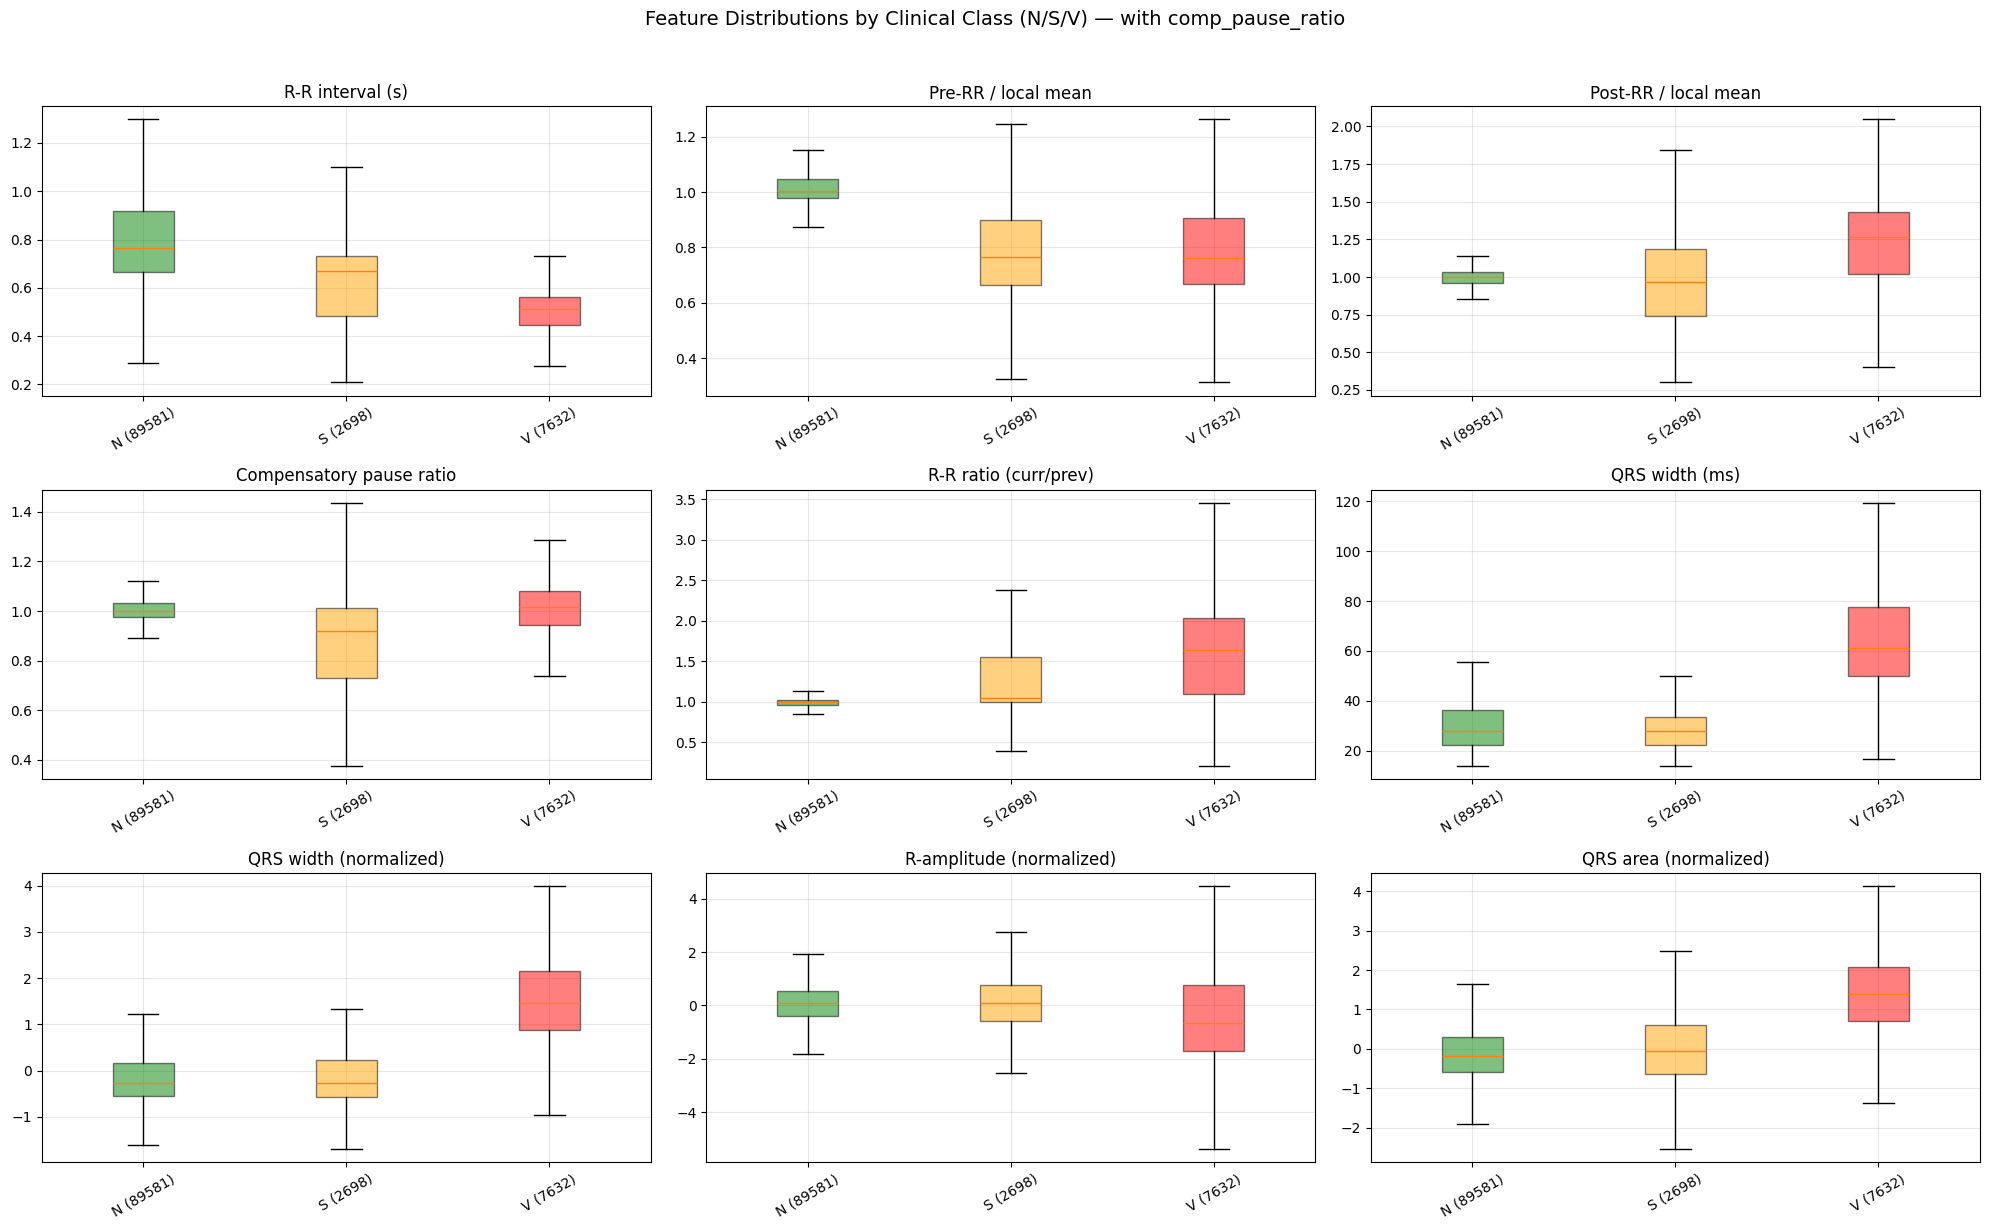

Median feature values by class:
                rr_prev  rr_prev_ratio_mean  rr_post_ratio_mean  comp_pause_ratio  rr_ratio  qrs_width_ms  qrs_width_ms_norm  r_amplitude_norm  qrs_area_norm
clinical_label                                                                                                                                               
N                 0.764               1.005               0.998             1.002     0.992        27.778             -0.262             0.088         -0.189
S                 0.669               0.764               0.968             0.918     1.047        27.778             -0.262             0.084         -0.053
V                 0.514               0.764               1.268             1.016     1.639        61.111              1.465            -0.656          1.383


In [12]:
# --- Visualize feature distributions by clinical class (N/S/V) ---

plot_features = ['rr_prev', 'rr_prev_ratio_mean', 'rr_post_ratio_mean', 'comp_pause_ratio',
                 'rr_ratio', 'qrs_width_ms', 'qrs_width_ms_norm', 'r_amplitude_norm', 'qrs_area_norm']
feature_names = ['R-R interval (s)', 'Pre-RR / local mean', 'Post-RR / local mean',
                 'Compensatory pause ratio', 'R-R ratio (curr/prev)',
                 'QRS width (ms)', 'QRS width (normalized)',
                 'R-amplitude (normalized)', 'QRS area (normalized)']

type_colors = {'N': 'green', 'S': 'orange', 'V': 'red'}
type_order = ['N', 'S', 'V']

fig, axes = plt.subplots(3, 3, figsize=(20, 12))
axes = axes.flatten()

for ax, feat, name in zip(axes, plot_features, feature_names):
    data, labels_plot, colors_plot = [], [], []
    for t in type_order:
        vals = df_all.loc[df_all['clinical_label'] == t, feat].dropna()
        if len(vals) > 0:
            data.append(vals)
            labels_plot.append(f"{t} ({len(vals)})")
            colors_plot.append(type_colors[t])
    bp = ax.boxplot(data, tick_labels=labels_plot, patch_artist=True, showfliers=False)
    for patch, color in zip(bp['boxes'], colors_plot):
        patch.set_facecolor(color); patch.set_alpha(0.5)
    ax.set_title(name); ax.grid(True, alpha=0.3); ax.tick_params(axis='x', rotation=30)

plt.suptitle('Feature Distributions by Clinical Class (N/S/V) — with comp_pause_ratio', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Median feature values by class:")
print(df_all.groupby('clinical_label')[plot_features].median().round(3).to_string())

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- AAMI DS1/DS2 inter-patient split ---
DS1_RECORDS = {'101', '106', '108', '109', '112', '114', '115', '116', '118', '119',
               '122', '124', '201', '203', '205', '207', '208', '209', '215', '220',
               '223', '230'}
DS2_RECORDS = {'100', '103', '105', '111', '113', '117', '121', '123', '200', '202',
               '210', '212', '213', '214', '219', '221', '222', '228', '231', '232',
               '233', '234'}

# Original features + RR context + per-patient normalized morphology + PCA waveform
feature_cols = [
    # Timing (original)
    'rr_prev', 'rr_curr', 'rr_ratio', 'hr_inst',
    # RR context — patient-normalized timing
    'rr_prev_ratio_mean', 'rr_post_ratio_mean', 'comp_pause_ratio',
    # Morphology (original)
    'r_amplitude', 'qrs_width_ms', 'qrs_area',
    'qrs_max', 'qrs_min', 'qrs_range', 'qrs_skew', 'qrs_kurt',
    # Per-patient normalized morphology
    'r_amplitude_norm', 'qrs_width_ms_norm', 'qrs_area_norm',
    # PCA beat waveform components
    'pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4',
    'pca_5', 'pca_6', 'pca_7', 'pca_8', 'pca_9',
]

df_model = df_all[df_all['clinical_label'].notna()].copy()
X = df_model[feature_cols].values
y = df_model['clinical_label'].values

train_mask = df_model['record'].isin(DS1_RECORDS)
test_mask = df_model['record'].isin(DS2_RECORDS)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"DS1 (train): {len(X_train)} beats, {len(DS1_RECORDS)} records")
print(f"DS2 (test):  {len(X_test)} beats, {len(DS2_RECORDS)} records")
print(f"Features:    {len(feature_cols)} (18 original + 10 PCA)")

print(f"\n{'Class':<8} {'Train':>8} {'Test':>8} {'Total':>8} {'Train%':>8}")
print(f"{'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*8}")
for c in ['N', 'S', 'V']:
    n_train = np.sum(y_train == c)
    n_test = np.sum(y_test == c)
    total = n_train + n_test
    print(f"{c:<8} {n_train:>8} {n_test:>8} {total:>8} {n_train/total*100:>7.1f}%")

DS1 (train): 50685 beats, 22 records
DS2 (test):  49226 beats, 22 records
Features:    28 (18 original + 10 PCA)

Class       Train     Test    Total   Train%
-------- -------- -------- -------- --------
N           45696    43885    89581    51.0%
S             929     1769     2698    34.4%
V            4060     3572     7632    53.2%


Classification Report (DS1/DS2 inter-patient split, N/S/V):

              precision    recall  f1-score   support

           N      0.953     0.998     0.975     43885
           S      0.548     0.019     0.037      1769
           V      0.976     0.882     0.927      3572

    accuracy                          0.954     49226
   macro avg      0.826     0.633     0.646     49226
weighted avg      0.941     0.954     0.938     49226



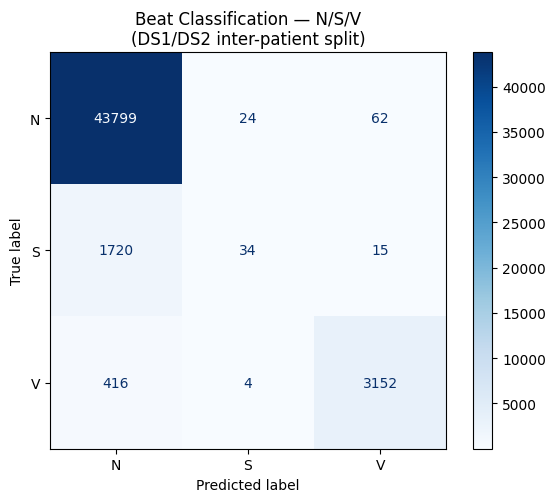

In [14]:
# --- Train Random Forest (N/S/V, DS1/DS2 inter-patient split) ---
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# --- Classification report ---
print("Classification Report (DS1/DS2 inter-patient split, N/S/V):\n")
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

# --- Confusion matrix ---
labels = ['N', 'S', 'V']
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Beat Classification — N/S/V\n(DS1/DS2 inter-patient split)')
plt.tight_layout()
plt.show()

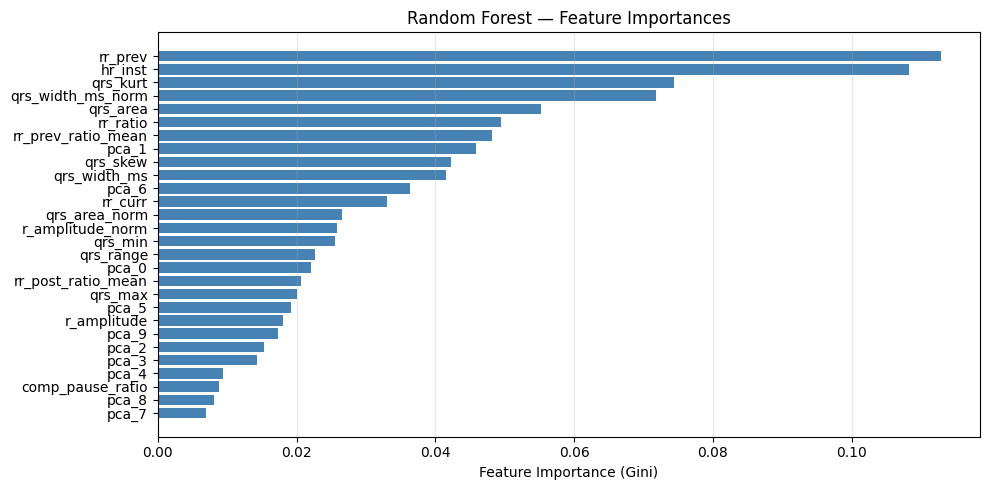

Feature importance ranking:
  1. rr_prev          0.1128
  2. hr_inst          0.1082
  3. qrs_kurt         0.0744
  4. qrs_width_ms_norm 0.0718
  5. qrs_area         0.0552
  6. rr_ratio         0.0495
  7. rr_prev_ratio_mean 0.0481
  8. pca_1            0.0459
  9. qrs_skew         0.0423
  10. qrs_width_ms     0.0415
  11. pca_6            0.0363
  12. rr_curr          0.0331
  13. qrs_area_norm    0.0265
  14. r_amplitude_norm 0.0259
  15. qrs_min          0.0255
  16. qrs_range        0.0227
  17. pca_0            0.0221
  18. rr_post_ratio_mean 0.0206
  19. qrs_max          0.0201
  20. pca_5            0.0192
  21. r_amplitude      0.0180
  22. pca_9            0.0173
  23. pca_2            0.0153
  24. pca_3            0.0143
  25. pca_4            0.0093
  26. comp_pause_ratio 0.0088
  27. pca_8            0.0081
  28. pca_7            0.0070


In [15]:
# --- Feature importance ---
importances = clf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(feature_cols)),
        importances[sorted_idx[::-1]],
        color='steelblue')
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels([feature_cols[i] for i in sorted_idx[::-1]])
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Feature Importances')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("Feature importance ranking:")
for rank, idx in enumerate(sorted_idx, 1):
    print(f"  {rank}. {feature_cols[idx]:<16s} {importances[idx]:.4f}")

In [16]:
# --- Gradient Boosting comparison (N/S/V, same DS1/DS2 split) ---
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight('balanced', y_train)

clf_gb = HistGradientBoostingClassifier(
    max_iter=300,
    max_depth=6,
    learning_rate=0.1,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42,
)
clf_gb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_gb = clf_gb.predict(X_test)

print("=== Gradient Boosting (HistGradientBoosting) ===\n")
print(classification_report(y_test, y_pred_gb, digits=3, zero_division=0))

=== Gradient Boosting (HistGradientBoosting) ===

              precision    recall  f1-score   support

           N      0.962     0.973     0.967     43885
           S      0.313     0.175     0.225      1769
           V      0.846     0.916     0.880      3572

    accuracy                          0.940     49226
   macro avg      0.707     0.688     0.691     49226
weighted avg      0.930     0.940     0.934     49226



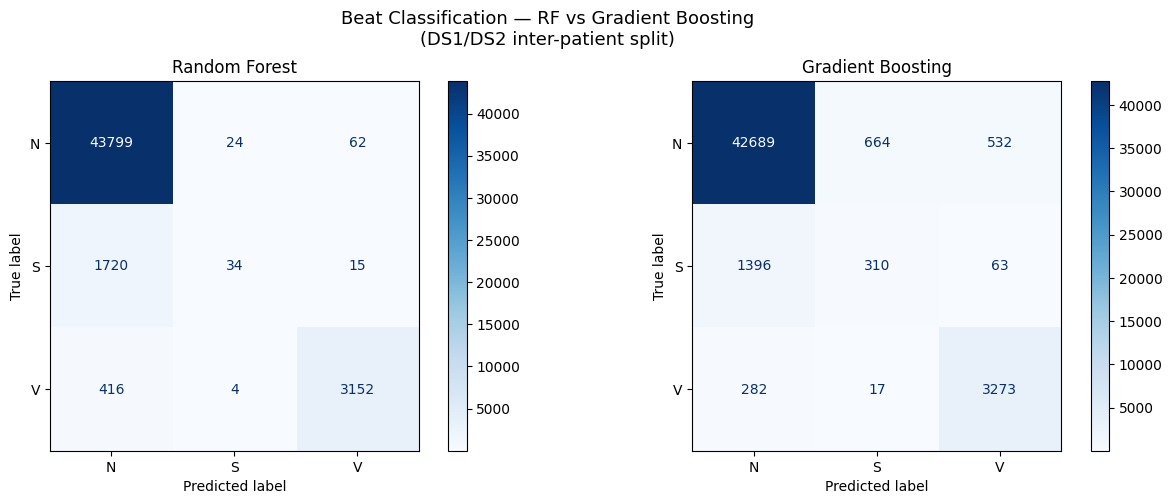


Metric                 Random Forest   Grad Boosting      Delta
-------------------- --------------- --------------- ----------
F1 N                           0.975           0.967     -0.008
F1 S                           0.037           0.225     +0.187
F1 V                           0.927           0.880     -0.047
Macro F1                       0.646           0.691     +0.044


In [17]:
# --- Side-by-side comparison: RF vs Gradient Boosting ---
from sklearn.metrics import f1_score

labels = ['N', 'S', 'V']
y_pred_rf = clf.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_p, title in zip(axes, [y_pred_rf, y_pred_gb],
                            ['Random Forest', 'Gradient Boosting']):
    cm = confusion_matrix(y_test, y_p, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(title)

plt.suptitle('Beat Classification — RF vs Gradient Boosting\n(DS1/DS2 inter-patient split)',
             fontsize=13)
plt.tight_layout()
plt.show()

# Compact comparison table
print(f"\n{'Metric':<20} {'Random Forest':>15} {'Grad Boosting':>15} {'Delta':>10}")
print(f"{'-'*20} {'-'*15} {'-'*15} {'-'*10}")
for c in labels:
    f1_rf = f1_score(y_test, y_pred_rf, labels=[c], average=None, zero_division=0)[0]
    f1_gb = f1_score(y_test, y_pred_gb, labels=[c], average=None, zero_division=0)[0]
    delta = f1_gb - f1_rf
    print(f"F1 {c:<17} {f1_rf:>15.3f} {f1_gb:>15.3f} {delta:>+10.3f}")

macro_rf = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)
macro_gb = f1_score(y_test, y_pred_gb, average='macro', zero_division=0)
print(f"{'Macro F1':<20} {macro_rf:>15.3f} {macro_gb:>15.3f} {macro_gb-macro_rf:>+10.3f}")

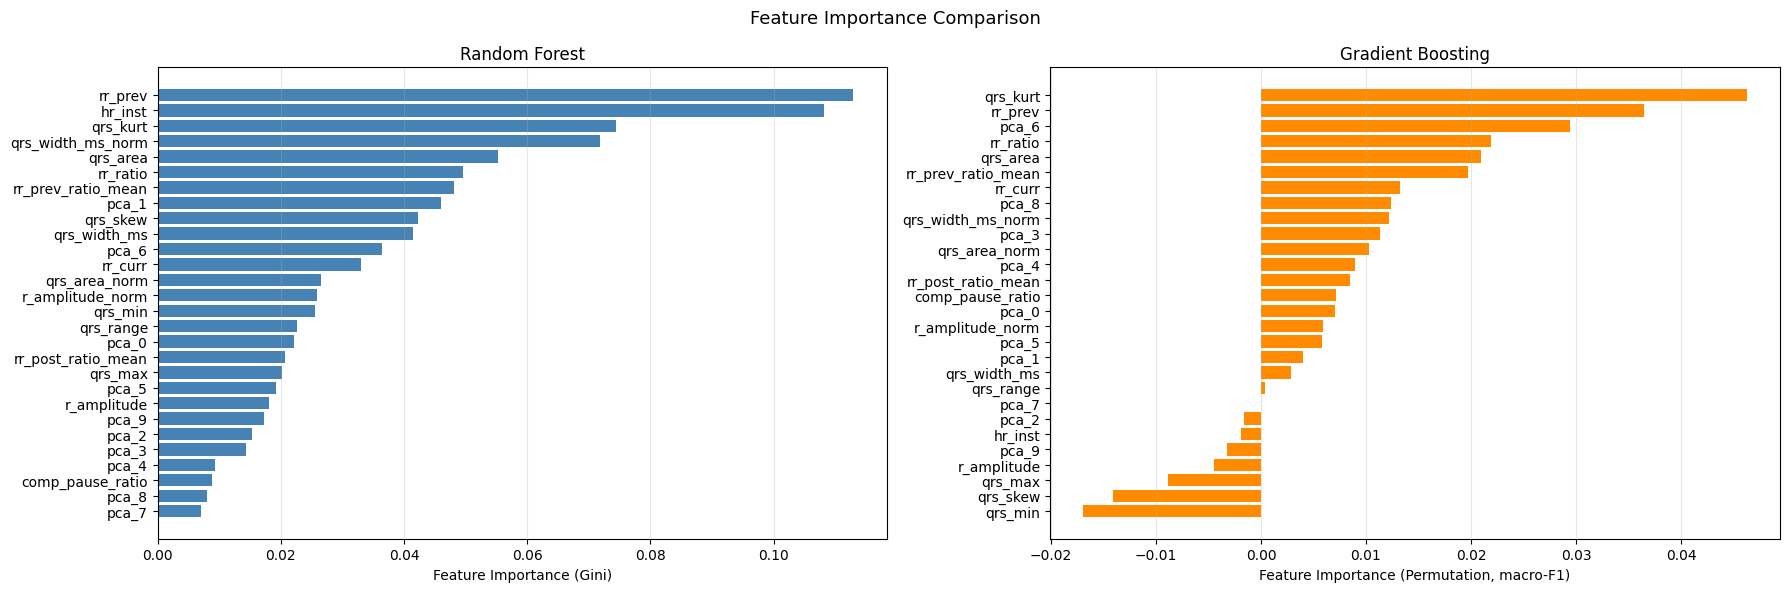

Gradient Boosting — Permutation importance ranking:
  1. qrs_kurt               0.0463
  2. rr_prev                0.0365
  3. pca_6                  0.0294
  4. rr_ratio               0.0219
  5. qrs_area               0.0210
  6. rr_prev_ratio_mean     0.0197
  7. rr_curr                0.0132
  8. pca_8                  0.0124
  9. qrs_width_ms_norm      0.0122
  10. pca_3                  0.0114
  11. qrs_area_norm          0.0103
  12. pca_4                  0.0089
  13. rr_post_ratio_mean     0.0085
  14. comp_pause_ratio       0.0071
  15. pca_0                  0.0071
  16. r_amplitude_norm       0.0059
  17. pca_5                  0.0058
  18. pca_1                  0.0040
  19. qrs_width_ms           0.0028
  20. qrs_range              0.0004
  21. pca_7                  0.0000
  22. pca_2                  -0.0016
  23. hr_inst                -0.0019
  24. pca_9                  -0.0033
  25. r_amplitude            -0.0045
  26. qrs_max                -0.0088
  27. qrs_skew  

In [18]:
# --- Feature importance comparison: RF vs Gradient Boosting ---
from sklearn.inspection import permutation_importance

# Permutation importance for GB (subsample for speed)
rng = np.random.RandomState(42)
subsample_idx = rng.choice(len(X_test), size=min(5000, len(X_test)), replace=False)
perm_result = permutation_importance(
    clf_gb, X_test[subsample_idx], y_test[subsample_idx],
    n_repeats=5, random_state=42, n_jobs=-1, scoring='f1_macro',
)
gb_importances = perm_result.importances_mean
gb_sorted_idx = np.argsort(gb_importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# RF importance (left) — Gini-based
rf_sorted = np.argsort(importances)[::-1]
axes[0].barh(range(len(feature_cols)), importances[rf_sorted[::-1]], color='steelblue')
axes[0].set_yticks(range(len(feature_cols)))
axes[0].set_yticklabels([feature_cols[i] for i in rf_sorted[::-1]])
axes[0].set_xlabel('Feature Importance (Gini)')
axes[0].set_title('Random Forest')
axes[0].grid(True, alpha=0.3, axis='x')

# GB importance (right) — permutation-based
axes[1].barh(range(len(feature_cols)), gb_importances[gb_sorted_idx[::-1]], color='darkorange')
axes[1].set_yticks(range(len(feature_cols)))
axes[1].set_yticklabels([feature_cols[i] for i in gb_sorted_idx[::-1]])
axes[1].set_xlabel('Feature Importance (Permutation, macro-F1)')
axes[1].set_title('Gradient Boosting')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Feature Importance Comparison', fontsize=13)
plt.tight_layout()
plt.show()

print("Gradient Boosting — Permutation importance ranking:")
for rank, idx in enumerate(gb_sorted_idx, 1):
    print(f"  {rank}. {feature_cols[idx]:<22s} {gb_importances[idx]:.4f}")

In [19]:
# --- Is r_amplitude actually discriminative within patients? ---
# Compare r_amplitude of S vs N beats WITHIN the same patient.
# If the difference disappears within-patient, the boxplot was misleading.

records_with_s = df_all[df_all['clinical_label'] == 'S']['record'].unique()

print("r_amplitude: S vs N within the same patient")
print(f"{'Record':<10} {'N median':>10} {'S median':>10} {'Diff':>10} {'S count':>10}")
print(f"{'-'*10} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")

diffs = []
for rec in sorted(records_with_s):
    rec_data = df_all[df_all['record'] == rec]
    n_amp = rec_data[rec_data['clinical_label'] == 'N']['r_amplitude']
    s_amp = rec_data[rec_data['clinical_label'] == 'S']['r_amplitude']
    if len(n_amp) > 0 and len(s_amp) > 0:
        diff = s_amp.median() - n_amp.median()
        diffs.append(diff)
        print(f"{rec:<10} {n_amp.median():>10.3f} {s_amp.median():>10.3f} {diff:>+10.3f} {len(s_amp):>10}")

print(f"\nMean within-patient difference: {np.mean(diffs):+.3f}")
print(f"Cross-patient difference:       {0.782 - 1.437:+.3f} (misleading aggregate)")

r_amplitude: S vs N within the same patient
Record       N median   S median       Diff    S count
---------- ---------- ---------- ---------- ----------
100             1.218      1.256     +0.038         33
101             1.527      1.571     +0.044          3
103             1.974      1.965     -0.009          2
108             0.335      0.708     +0.374          4
112             0.768      0.757     -0.011          2
113             2.118      1.957     -0.161          6
114            -0.184     -0.398     -0.214         12
116             3.025      3.322     +0.297          1
117            -0.580     -0.286     +0.293          1
118             1.333      1.516     +0.184         95
121             0.841      0.749     -0.092          1
124             2.206      2.085     -0.121         31
200             1.039      1.023     -0.016         29
201             1.000      0.505     -0.495        128
202             1.475      1.346     -0.129         54
203             1.301